<a href="https://colab.research.google.com/github/c-lydia/gpt/blob/main/gpt_v0_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GPT Transformer

A minimal GPT-style language model trained on Project Gutenberg books. Built from first principles: custom BPE tokenizer, multi-head self-attention, sinusoidal positional encoding, and top-k/top-p text generation.

---

**Contents**
1. Key Concepts
2. Architecture Explanation
3. Tokenizer
4. Training Process
5. Training Concepts
6. Analysis — Data and Performance
7. Implementation


---
# Part I — Concepts

---

## Key Concepts

---

### Attention and Self-Attention

Attention is the mechanism that lets the model dynamically decide which other tokens are relevant when processing a given token. In **self-attention**, queries, keys, and values all come from the same sequence — so every token attends to every other token in the input (subject to the causal mask).

This is qualitatively different from an RNN, which can only access past tokens through a fixed-size hidden state. A transformer can directly compare any two tokens regardless of how far apart they are in the sequence, which is why transformers are much better at tasks requiring long-range reasoning.

---

### Residual Connections

Every transformer block adds its output to its input (`x = x + sublayer(x)`), creating a "residual stream" that flows through the entire network. This has two important effects: gradients flow directly back to early layers without being multiplied through every block (solving vanishing gradients), and the model can learn the identity function easily (by zeroing out the sublayer's output). Deep networks without residuals are practically untrainable.

---

### Layer Normalization

LayerNorm normalizes the activations across the feature dimension (not the batch dimension, unlike BatchNorm). For each token's `d_model`-dimensional vector, it computes the mean and variance across those dimensions and normalizes. This stabilizes training by preventing activations from growing or shrinking across layers, and it makes the model robust to different scales of input.

---

### Autoregressive Generation

The model is trained with teacher forcing: the correct previous tokens are always fed as input, even if the model would have predicted something else. At inference time, this changes — the model must use its own previously generated tokens as input. This is called **autoregressive** generation, and it means generation errors can compound: a bad token early on shifts the distribution for all future tokens.

---

### Temperature and Sampling

After computing logits for the next token, you don't have to take the argmax (greedy decoding). Dividing logits by a **temperature** parameter and sampling from the resulting distribution introduces controlled randomness. Temperature 1.0 = standard sampling; < 1.0 = more peaked (repetitive but coherent); > 1.0 = flatter (creative but potentially incoherent). Top-k and top-p filtering further constrain which tokens can be sampled.

---

### Sequence Length and Context Window

The model uses `max_seq_len = 512` and is trained with `seq_len = 256`. This limits how much context the model can use during generation — it can only attend to the previous 256 tokens. Modern large language models use context windows of 8k–200k tokens; scaling beyond this requires techniques like rotary positional embeddings or sliding window attention.

---

### Parameters and Model Capacity

The updated model has four transformer layers, `d_model = 256`, and four attention heads. The total parameter count is dominated by the embedding matrix (`vocab_size × d_model = 8000 × 256 = 2M parameters`) and the LM head. More parameters allow the model to memorize more patterns, but also require more data and compute to train well.

---


## Architecture Explanation

The GPT model implemented here is a **decoder-only transformer**, meaning it only uses the decoder half of the original "Attention Is All You Need" architecture. There is no encoder and no cross-attention — the model simply reads a sequence of tokens and learns to predict what comes next.

---

### Token and Positional Embeddings

The first thing the model does is convert token IDs into continuous vectors. Each unique token in the vocabulary gets its own learnable `d_model`-dimensional vector via `nn.Embedding`. These vectors are random at initialization and gradually take on meaning through training.

However, the embedding alone carries no information about *where* in the sequence a token appears — attention is order-agnostic by design. To fix this, **sinusoidal positional encodings** are added to the embeddings before the first transformer block. The encoding for position `pos` and dimension `i` is:

```
PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))
```

This deterministic scheme (no learned parameters) lets the model generalize to sequence lengths not seen during training, and the sinusoidal structure means nearby positions have similar encodings while distant ones differ.

---

### TransformerBlock

The core repeating unit. This implementation uses **pre-norm** ordering, meaning LayerNorm is applied *before* each sub-layer rather than after. Pre-norm is more numerically stable and tends to train faster:

```
x = x + MultiHeadAttention(LayerNorm(x))
x = x + FeedForward(LayerNorm(x))
```

The residual connections (the `x +` part) are critical — they give gradients a direct path back to early layers and allow very deep networks to train without vanishing gradients.

---

### Multi-Head Attention

This is the central mechanism. Each token produces three vectors by applying separate learned linear projections to its embedding: a **query** Q (what am I looking for?), a **key** K (what do I contain?), and a **value** V (what do I return if selected?).

Attention scores between all pairs of tokens are computed as:

```
Attention(Q, K, V) = softmax( QKᵀ / √d_k ) · V
```

The `√d_k` scaling factor prevents the dot products from growing so large that softmax saturates (which would cause vanishingly small gradients).

**Multi-head** means this entire process is run `num_heads` times in parallel, each with its own Q/K/V projections operating on a `d_k = d_model / num_heads` subspace. Different heads can specialize — one might learn syntactic dependencies, another semantic similarity, another coreference. Their outputs are concatenated and projected back to `d_model`.

---

### Causal Mask

Because the model is trained to predict the *next* token, it must not be allowed to look at future tokens when computing attention. This is enforced by a **causal (upper-triangular) mask**: before the softmax, all attention scores where the key position is greater than the query position are set to `-inf`, which becomes 0 after softmax. The result is that each token can only attend to itself and tokens before it.

---

### Feed-Forward Network

After attention, each position passes through an identical two-layer MLP:

```
FFN(x) = Dropout(ReLU(W₁x + b₁))W₂ + b₂
```

The hidden dimension is `4 × d_model`. This is applied independently and identically at every sequence position — no information is shared between positions here. If attention is where the model decides *which* positions are relevant, the FFN is where it does the actual computation on that information.

---

### LM Head and Output

After passing through all transformer blocks, a final `LayerNorm` is applied, then a linear layer (`lm_head`) maps the `d_model`-dimensional representation at each position to a `vocab_size`-dimensional vector of **logits**. These are unnormalized log-probabilities over the vocabulary — the token with the highest logit is the model's most confident prediction for the next token at that position.

---

## Tokenizer

Before text can be processed by a neural network, it must be converted to numbers. A tokenizer defines the mapping between raw text and the integer IDs the model operates on.

---

### Why Not Characters or Words?

A **character-level** vocabulary is tiny (around 100 tokens for English), but representing even a short sentence requires hundreds of tokens, making sequences impractically long for attention (which is O(n²) in sequence length).

A **word-level** vocabulary avoids long sequences but explodes in size — English has hundreds of thousands of word forms, and any word not seen during training becomes an unknown token. Morphologically rich languages are even worse.

**Subword tokenization** is the standard solution. Common words and common prefixes/suffixes become single tokens; rare words are split into recognizable pieces. "running" might be one token; "uncharacteristically" might be split into ["un", "character", "istically"].

---

### How BPE Works

This implementation trains a BPE tokenizer from scratch:

**1. Pre-tokenization.** The corpus is split into "words" using the regex `r"\w+|[^\w\s]|\s+"`. This separates alphabetic runs, individual punctuation characters, and whitespace runs — a deliberate choice to prevent merges from spanning word boundaries.

**2. Character vocabulary initialization.** Every unique character in the corpus becomes an initial token. The vocabulary starts small (around 90 tokens for the Gutenberg corpus).

**3. Iterative merging.** In each step:
- Count every adjacent pair of tokens across all words, weighted by word frequency.
- Find the most frequent pair, e.g., `('e', 's')`.
- Create a new token `"es"` and record the merge rule `('e', 's') → "es"`.
- Replace all occurrences of that pair in the word representations.
- Repeat until `target_vocab_size` is reached.

The merge rules are learned in frequency order. Common short sequences get merged first (spaces, "th", "he", "in"), then longer patterns ("the", "ing", "tion") as vocabulary slots fill up.

**4. Encoding new text.** To encode unseen text, the same pre-tokenization regex is applied, then the learned merge rules are applied in the order they were learned. The word is greedily merged from left to right, rule by rule, until no more rules apply.

**5. Decoding.** Since tokens map directly to substrings, decoding is trivial: look up each ID in `idx_to_token` and concatenate.

---

### Round-Trip Property

A well-implemented BPE tokenizer satisfies `decode(encode(text)) == text` — the tokenization is lossless. This is verified with an assertion after training. Vocabulary size of 300 is small by modern standards (GPT-2 uses 50,257) but sufficient for a from-scratch demonstration on ~28M characters.

---

## Training Process

Training a language model means teaching it to predict the next token in a sequence. Every step of the process is structured around that single objective.

---

### Data Preparation

The full Gutenberg corpus is encoded into a flat 1D tensor of token IDs. This is done in 100,000-character chunks (`chunk_encode`) to avoid timeouts from feeding the entire ~28M character string to the tokenizer at once.

The resulting tensor is split 90/10 into `train_ids` and `val_ids`. No special shuffling is needed — `get_batch` samples random starting positions at each step, so the model sees the data in different orderings across batches.

---

### Batch Construction (`get_batch`)

Each training step draws a batch of random sequence windows from the token tensor. For a window starting at position `i`:
- `x[i : i+seq_len]` is the input
- `y[i+1 : i+seq_len+1]` is the target (the same window shifted right by one)

At each of the `seq_len` positions, the model produces a prediction, and the loss is computed against the actual next token at that position. A single batch therefore provides `batch_size × seq_len` training examples, which is why language model training is so data-efficient compared to classification.

---

### Forward Pass

The batch `x` (shape `[batch_size, seq_len]`) passes through the full model — embeddings → transformer blocks → LM head — producing `logits` of shape `[batch_size, seq_len, vocab_size]`.

---

### Loss Calculation

Cross-entropy loss is computed between the logits and the targets. Both tensors are reshaped to `[batch_size × seq_len, vocab_size]` and `[batch_size × seq_len]` respectively, so `nn.CrossEntropyLoss` can process all positions in one call.

A model predicting randomly over a vocabulary of size 300 would have a cross-entropy loss of `log(300) ≈ 5.7`. As the model learns, this should drop to around 1.5–2.0 for a well-trained small model.

---

### Backward Pass and Optimization

After computing the loss:
1. `optimizer.zero_grad()` clears accumulated gradients from the previous step.
2. `loss.backward()` computes gradients via backpropagation through the entire computation graph.
3. `torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)` clips the global gradient norm to 1.0, preventing exploding gradients.
4. `optimizer.step()` updates all parameters using AdamW.

---

### Validation and Checkpointing

Every 50 steps within an epoch, the model switches to `eval()` mode (disables dropout), draws a validation batch, and computes validation loss without gradients (`torch.no_grad()`). If this is the lowest validation loss seen so far, the model state is saved to `best_model.pt`. This checkpoint is what gets loaded for text generation.

---

### Learning Rate Schedule

`CosineAnnealingLR` decays the learning rate from the initial value following a cosine curve to near zero over `num_epochs`. This gives the model aggressive early learning followed by fine-grained convergence at the end.

---


## Training Concepts

---

### Cross-Entropy Loss

The model outputs logits — one score per vocabulary token at each sequence position. Cross-entropy converts these into a probability distribution (via softmax) and measures how much probability was assigned to the correct token. Formally, for a correct token `t`:

```
L = -log P(t)
```

If the model assigns probability 1.0 to the correct token, loss = 0. If it assigns probability 0.01, loss = 4.6. The goal of training is to minimize the average loss over all positions and batches. Because it's applied at every position in every sequence, a single training step on a batch of 32 × 128 tokens computes loss over 4,096 predictions simultaneously.

---

### Gradient Descent and Backpropagation

The model's parameters are adjusted to reduce loss using **gradient descent**. The gradient of the loss with respect to each parameter tells us the direction in which that parameter should move to increase the loss — so we move in the opposite direction. **Backpropagation** is the algorithm that computes these gradients efficiently by applying the chain rule backward through the computation graph.

---

### AdamW

Plain gradient descent uses the same learning rate for every parameter. **Adam** improves on this by maintaining a running estimate of the first moment (mean gradient) and second moment (uncentered variance) for each parameter, and using these to adapt the effective learning rate per parameter. Parameters with consistently large gradients get smaller updates; parameters with small or noisy gradients get larger ones.

**AdamW** separates weight decay from the gradient update (unlike the original Adam, which conflates them). Weight decay is an L2 regularization term that pushes parameter values toward zero, discouraging the model from over-relying on any single weight.

---

### Gradient Clipping

In deep transformers, gradients can occasionally spike to very large values — particularly early in training when the model is far from a good solution. If a large gradient update overshoots a good region of parameter space, training can diverge. Clipping rescales the entire gradient vector to have a maximum norm of 1.0 before the update, without changing its direction.

---

### Dropout

During training, dropout randomly zeros out a fraction of activations in the feed-forward and attention layers. This forces the model to not rely on any single neuron, acting as a regularizer. At inference time (`.eval()` mode), dropout is disabled and all activations are used.

---

### Overfitting and the Train/Validation Split

A model with enough parameters can memorize its training data rather than learning generalizable patterns. The **validation set** — data never used in gradient updates — is used to detect this. If training loss keeps falling but validation loss plateaus or rises, the model is overfitting. Saving the checkpoint at the lowest validation loss rather than the final epoch is a standard guard against this.

---

### Epochs and Steps

One **epoch** is a full pass over the training data. In this implementation, each epoch is approximated by 100 random batches rather than an exhaustive scan of the corpus — at 28M+ tokens, exhaustive scanning would be extremely slow. The effective coverage per epoch grows with `batch_size × seq_len × 100 = 32 × 128 × 100 = 409,600` tokens, which is about 1.4% of the training set per epoch.

---

## Analysis — Data and Performance

---

### Dataset

The training corpus is assembled from Project Gutenberg, a collection of public domain books. The `download_gutenberg_books` function pulls books by their Gutenberg IDs and strips the header/footer metadata using the `***` delimiters.

With `num_books = 500` and the available book list, the corpus reaches approximately **28 million characters** after concatenation. This is a small dataset by NLP standards — GPT-2 was trained on 40 billion tokens — but sufficient for a from-scratch demonstration.

**Character distribution.** A character frequency analysis of the corpus shows the expected distribution: space is the most common character (~14–17% of all characters), followed by 'e', 't', 'a', 'o', 'i', 'n'. Punctuation accounts for a small but non-trivial fraction. The full character vocabulary is approximately 91 unique characters, including uppercase and lowercase letters, digits, punctuation, and whitespace variants.

---

### Tokenizer Analysis

Training a BPE tokenizer with `target_vocab_size = 300` on the full 28M character corpus yields **~209 merge rules** on top of the ~91-character base vocabulary. The merges capture common English subwords: short function words ("the", "in", " and"), common affixes ("ing", "tion", "ed"), and frequent character bigrams.

**Tokenization density** (tokens per character) is a measure of compression efficiency. On the test string "Alice was beginning to get very tired of sitting by her sister" (62 characters):
- A character-level tokenizer would produce 62 tokens (density = 1.0 tokens/char).
- This BPE tokenizer produces around 28–32 tokens (density ~0.45–0.52 tokens/char), roughly halving sequence length compared to character-level.

Training on a larger corpus improves generalization but can slightly *reduce* density on corpus-specific test strings: a tokenizer trained on only the Alice books learns Alice-specific patterns aggressively, while one trained on 28M diverse characters spreads its merge budget across many domains.

---

### Training Performance

The model configuration (`d_model = 128`, `num_heads = 4`, `num_layers = 4`, `dropout = 0.1`) gives roughly **1.3–1.6 million parameters** depending on vocabulary size.

**Loss baseline.** With a vocabulary of 300 tokens, a randomly initialized model has a theoretical cross-entropy loss of `log(300) ≈ 5.7`. In practice, the model reaches this quickly in the first few steps.

**Expected convergence.** After 40 epochs of 100 batches each (approximately 56 million token-position predictions), the model typically achieves a validation loss in the range of **1.5–1.8**. This corresponds to a perplexity of roughly `e^1.6 ≈ 5`, meaning on average the model assigns roughly 1-in-5 probability to the correct next token — significantly better than the baseline but far from human-level fluency.

**Generated text quality.** At this scale, the model learns basic statistical properties of English: common word forms, plausible punctuation, and rough sentence structure. It does not learn deep semantics or long-range coherence. Outputs tend to be grammatically plausible at the phrase level but drift into incoherence over longer passages. This is expected — scaling law research has shown that language model quality improves predictably with model size, dataset size, and compute, and this model is near the lower end of all three.

**What limits performance here:**
- Vocabulary size (300) is extremely small; most words require multiple tokens even for common ones.
- `d_model = 128` and 4 layers give limited representational capacity.
- The corpus (~28M characters) encodes to roughly ~13M tokens at this vocabulary size — enough to train something functional, but small compared to modern pretraining runs.


---
# Part II — Implementation

## 1. Setup

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
from pathlib import Path
import urllib.request
from tqdm import tqdm
import os

if torch.cuda.is_available():
  device = torch.device('cuda')
else:
  device = torch.device('cpu')

print(f'Use device: {device}')

if device.type == 'cuda':
  print(f'GPU: {torch.cuda.get_device_name()}')
  print(f'VRAM: {torch.cuda.get_device_properties(device).total_memory / 1e9:.1f}GB')

Use device: cuda
GPU: Tesla T4
VRAM: 15.6GB


## 2. Data

Downloads books from Project Gutenberg and concatenates them into a single text corpus. Books with `***` delimiters have their metadata stripped automatically.

In [ ]:
import urllib
import urllib.request

def download_gutenberg_books(num_books = 500, extra_books_data=None):
    books = {
        10:    "The King James Version of the Bible",
        11:    "Alice's Adventures in Wonderland",
        16:    "Peter Pan",
        23:    "Narrative of the Life of Frederick Douglass",
        35:    "The Time Machine",
        36:    "The Island of Doctor Moreau",
        37:    "The Invisible Man",
        41:    "The Legend of Sleepy Hollow",
        43:    "The Strange Case of Dr. Jekyll and Mr. Hyde",
        45:    "Anne of Green Gables",
        46:    "A Christmas Carol",
        55:    "The Wonderful Wizard of Oz",
        74:    "The Adventures of Tom Sawyer",
        76:    "Adventures of Huckleberry Finn",
        84:    "Frankenstein",
        98:    "A Tale of Two Cities",
        100:   "The Complete Works of William Shakespeare",
        120:   "Treasure Island",
        135:   "Les Misérables",
        141:   "The Adventures of Pinocchio",
        145:   "Middlemarch",
        161:   "Sense and Sensibility",
        165:   "McTeague: A Story of San Francisco",
        174:   "The Picture of Dorian Gray",
        205:   "Walden",
        209:   "The Turn of the Screw",
        215:   "The Call of the Wild",
        219:   "Heart of Darkness",
        244:   "A Study in Scarlet",
        345:   "Dracula",
        394:   "Cranford",
        408:   "The Souls of Black Folk",
        514:   "Little Women",
        600:   "Notes from the Underground",
        612:   "The Odyssey",
        730:   "Oliver Twist",
        768:   "Wuthering Heights",
        829:   "Gulliver's Travels",
        844:   "The Importance of Being Earnest",
        996:   "Don Quixote",
        1023:  "Bleak House",
        1080:  "A Modest Proposal",
        1111:  "Vanity Fair",
        1184:  "The Iliad",
        1220:  "Ivanhoe",
        1232:  "The Prince",
        1254:  "The Yellow Wallpaper",
        1259:  "Twenty Years After",
        1260:  "Jane Eyre",
        1268:  "The Count of Monte Cristo",
        1342:  "Pride and Prejudice",
        1399:  "Anna Karenina",
        1400:  "Great Expectations",
        1497:  "The Republic",
        1500:  "A Midsummer Night's Dream",
        1501:  "A Doll's House",
        1513:  "Romeo and Juliet",
        1524:  "Hamlet",
        1534:  "Macbeth",
        1661:  "The Adventures of Sherlock Holmes",
        1719:  "The Ballad of the White Horse",
        1727:  "The Hound of the Baskervilles",  # NOTE: 1727 was misused — keeping for Odyssey below, see 612
        1952:  "The Hound of the Baskervilles",
        1998:  "Thus Spake Zarathustra",
        2148:  "The Works of Edgar Allan Poe, Vol. 2",
        2160:  "The Expedition of Humphry Clinker",
        2554:  "Crime and Punishment",
        2591:  "Grimms' Fairy Tales",
        2600:  "War and Peace",
        2641:  "A Room with a View",
        2680:  "Meditations",
        2701:  "Moby Dick",
        3206:  "Moby Multiple Language Lists of Common Words",
        3207:  "Leviathan",
        3296:  "The Confessions of St. Augustine",
        3300:  "The Wealth of Nations",
        4085:  "The Great Gatsby",
        4300:  "Ulysses",
        4363:  "Beyond Good and Evil",
        5197:  "My Life — Volume 1 (Wagner)",
        5200:  "Metamorphosis",
        5230:  "The Scarlet Letter",
        5976:  "The War of the Worlds",
        6130:  "The Jungle Book",
        6151:  "The Secret Garden",
        6271:  "Embers",
        6593:  "The History of Tom Jones, a Foundling",
        6761:  "The Adventures of Ferdinand Count Fathom",
        7290:  "韓詩外傳",
        7370:  "Second Treatise of Government",
        7735:  "Paul Clifford",
        8492:  "The King in Yellow",
        8800:  "The Divine Comedy",
        11844: "David Copperfield",
        15399: "The Interesting Narrative of Olaudah Equiano",
        16328: "Beowulf",
        16389: "The Enchanted April",
        20203: "Autobiography of Benjamin Franklin",
        20228: "Noli Me Tangere",
        20417: "The Outline of Science, Vol. 1",
        20738: "Diccionario Ingles-Español-Tagalog",
        23908: "夢中緣",
        23962: "西遊記",
        24141: "警世通言",
        24855: "Concrete Construction: Methods and Costs",
        24979: "A Source Book for Ancient Church History",
        26184: "Simple Sabotage Field Manual",
        26471: "Spoon River Anthology",
        26706: "Manual of Military Training",
        27166: "吶喊",
        27673: "Oedipus King of Thebes",
        28054: "The Brothers Karamazov",
        28189: "My Friends the Savages",
        29951: "The Mayflower, January 1905",
        30254: "The Romance of Lust",
        32105: "Belford's Magazine, Vol. 2 No. 2",
        33170: "The Itching Palm",
        34901: "On Liberty",
        36034: "White Nights and Other Stories",
        37106: "Little Women (Alcott, alt. ed.)",
        37683: "Chambers's Twentieth Century Dictionary (part 1 of 4: A-D)",
        45304: "The City of God, Vol. I",
        45368: "The Outline of History",
        50285: "Dr. Mabuse, der Spieler",
        57724: "A Cyclopaedia of Canadian Biography",
        64317: "The Great Gatsby (alt. ed.)",
        67979: "The Blue Castle",
        71937: "The Writings of Clement of Alexandria, Vol. 1",
        72075: "The Scrap Book, Vol. 2 No. 2",
        72679: "The Lesser Key of Solomon",
        2097:  "Around the World in Eighty Days",   # ~280KB
        2800:  "The Idiot",                         # ~1.1MB
        3090:  "The Three Musketeers",              # ~800KB
        1257:  "The Essays of Montaigne, Vol. 1",   # ~600KB
        4276:  "The Life of Samuel Johnson",        # ~1.2MB
        5758:  "The Oregon Trail",                  # ~400KB
        969:   "Kim",                               # ~450KB
        203:   "Uncle Tom's Cabin",                 # ~1MB
        580:   "The Decameron, Vol. I",             # ~600KB
        23344: "Agnes Grey",
    }

    if extra_books_data is not None:
        books.update(extra_books_data)

    all_text = ''

    for book_id in list(books.keys())[:min(num_books, len(books))]:
        title = books[book_id]
        url = f'https://www.gutenberg.org/ebooks/{book_id}.txt.utf-8'

        try:        # ← 4 spaces indent
            print(f'Downloading: {title}...', end='')

            with urllib.request.urlopen(url, timeout=10) as response:
                text = response.read().decode('utf-8')

            if '***' in text:
                parts = text.split('***')
                if len(parts) >= 3:
                    text = parts[2]
                else:
                    text = parts[0]

            all_text += text + '\n\n'
            size_kb = len(text) / 1024
            print(f'size: {size_kb:.0f}KB')
        except Exception as e:
            print(f'Error downloading {title}: {e}')

    return all_text, books # Modified to return books dictionary

print('Downloading text data...\n')
# Ensure book_data is defined before calling download_gutenberg_books, it is defined in 14b9e7cb
if 'book_data' not in globals():
    book_data = {}
text_data, updated_books = download_gutenberg_books(num_books = 500, extra_books_data=book_data) # Capture updated_books
print(f'Total downloaded text length: {len(text_data)} characters')

# Print a sample of the updated books to verify
print(f'\nTotal books in updated dictionary: {len(updated_books)}')
print('\nSample of updated books:')
count = 0
for book_id, title in updated_books.items():
    print(f'ID: {book_id}, Title: {title}')
    count += 1
    if count >= 10: # Print first 10 items as a sample
        break


Downloading: The King James Version of the Bible...size: 3331KB
Downloading: Alice's Adventures in Wonderland...size: 145KB
Downloading: Peter Pan...size: 256KB
Downloading: Narrative of the Life of Frederick Douglass...size: 222KB
Downloading: The Time Machine...size: 179KB
Downloading: The Island of Doctor Moreau...size: 336KB
Downloading: The Invisible Man...size: 4KB
Downloading: The Legend of Sleepy Hollow...size: 69KB
Downloading: The Strange Case of Dr. Jekyll and Mr. Hyde...size: 138KB
Downloading: Anne of Green Gables...size: 559KB
Downloading: A Christmas Carol...size: 158KB
Downloading: The Wonderful Wizard of Oz...size: 208KB
Downloading: The Adventures of Tom Sawyer...size: 392KB
Downloading: Adventures of Huckleberry Finn...size: 569KB
Downloading: Frankenstein...size: 417KB
Downloading: A Tale of Two Cities...size: 641KB
Downloading: The Complete Works of William Shakespeare...size: 5425KB
Downloading: Treasure Island...size: 363KB
Downloading: Les Misérables...size: 85

## 3. BPE Tokenizer

Trains a byte-pair encoding tokenizer from scratch on the full corpus. Produces `tokenizer.vocab`, `tokenizer.encode()`, and `tokenizer.decode()`. Includes a round-trip assertion to verify lossless encoding.

In [ ]:
import re
from collections import Counter, defaultdict

class BpeTokenizer:
    def __init__(self, special_tokens=None):
        self.special_tokens = special_tokens if special_tokens is not None else ["<|endoftext|>"]
        self.merges = {}
        self.vocab = list(self.special_tokens)
        self.token_to_idx = {t: i for i, t in enumerate(self.vocab)}
        self.idx_to_token = {i: t for t, i in self.token_to_idx.items()}

    def _add_to_vocab(self, token):
        if token not in self.token_to_idx:
            idx = len(self.vocab)
            self.vocab.append(token)
            self.token_to_idx[token] = idx
            self.idx_to_token[idx] = token

    def train(self, corpus, target_vocab_size):
        print("Pre-tokenizing...")
        words = re.findall(r"\w+|[^\w\s]|\s+", corpus)
        word_freqs = Counter(words)

        for char in sorted(set("".join(word_freqs.keys()))):
            self._add_to_vocab(char)

        splits = {word: list(word) for word in word_freqs}

        # Build pair_freqs and pair->words index once
        print("Building pair index...")
        pair_freqs = defaultdict(int)
        pair_to_words = defaultdict(set)
        for word, split in splits.items():
            for i in range(len(split) - 1):
                pair = (split[i], split[i+1])
                pair_freqs[pair] += word_freqs[word]
                pair_to_words[pair].add(word)

        num_merges = target_vocab_size - len(self.vocab)
        print(f"Learning {num_merges} merges...")

        for step in range(num_merges):
            if not pair_freqs:
                break

            best_pair = max(pair_freqs, key=pair_freqs.get)
            if pair_freqs[best_pair] < 2:
                break

            new_token = "".join(best_pair)
            self.merges[best_pair] = new_token
            self._add_to_vocab(new_token)

            # Only update words containing this pair
            for word in pair_to_words.pop(best_pair, set()):
                old_split = splits[word]
                freq = word_freqs[word]

                # Remove all pair contributions from old split
                for i in range(len(old_split) - 1):
                    p = (old_split[i], old_split[i+1])
                    pair_freqs[p] -= freq
                    if pair_freqs[p] <= 0:
                        del pair_freqs[p]
                    pair_to_words[p].discard(word)

                # Apply merge
                new_split = []
                i = 0
                while i < len(old_split):
                    if i < len(old_split) - 1 and old_split[i] == best_pair[0] and old_split[i+1] == best_pair[1]:
                        new_split.append(new_token)
                        i += 2
                    else:
                        new_split.append(old_split[i])
                        i += 1
                splits[word] = new_split

                # Add new pair contributions from new split
                for i in range(len(new_split) - 1):
                    p = (new_split[i], new_split[i+1])
                    pair_freqs[p] += freq
                    pair_to_words[p].add(word)

            if (step + 1) % 500 == 0:
                print(f"  {step+1}/{num_merges} merges, vocab: {len(self.vocab)}")

        print(f"Done. {len(self.merges)} merges, vocab size: {len(self.vocab)}")

    def encode(self, text):
        merge_rank = {pair: i for i, pair in enumerate(self.merges)}
        words = re.findall(r"\w+|[^\w\s]|\s+", text)
        tokens = []
        for word in words:
            split = list(word)
            while True:
                best_rank = float('inf')
                best_idx = -1
                for i in range(len(split) - 1):
                    rank = merge_rank.get((split[i], split[i+1]), float('inf'))
                    if rank < best_rank:
                        best_rank = rank
                        best_idx = i
                if best_idx == -1:
                    break
                pair = (split[best_idx], split[best_idx+1])
                split = split[:best_idx] + [self.merges[pair]] + split[best_idx+2:]
            tokens.extend(split)
        return [self.token_to_idx[t] for t in tokens if t in self.token_to_idx]

    def decode(self, ids):
        return "".join(self.idx_to_token[i] for i in ids if i in self.idx_to_token)


# Train on 10M char sample — enough to learn 8000 merges
tokenizer = BpeTokenizer()
print(f"Training on {10_000_000:,} characters...")
tokenizer.train(text_data[:10_000_000], target_vocab_size=8000)

test = "Alice was beginning to get very tired of sitting by her sister"
assert tokenizer.decode(tokenizer.encode(test)) == test
print("Round-trip OK")

Training on 10,000,000 characters...
Pre-tokenizing...
Building pair index...
Learning 7892 merges...
  500/7892 merges, vocab: 608
  1000/7892 merges, vocab: 1108
  1500/7892 merges, vocab: 1608
  2000/7892 merges, vocab: 2108
  2500/7892 merges, vocab: 2608
  3000/7892 merges, vocab: 3108
  3500/7892 merges, vocab: 3608
  4000/7892 merges, vocab: 4108
  4500/7892 merges, vocab: 4608
  5000/7892 merges, vocab: 5108
  5500/7892 merges, vocab: 5608
  6000/7892 merges, vocab: 6108
  6500/7892 merges, vocab: 6608
  7000/7892 merges, vocab: 7108
  7500/7892 merges, vocab: 7608
Done. 7892 merges, vocab size: 8000
Round-trip OK


## 4. GPT Model

Defines `MultiHeadAttention`, `FeedForward`, `TransformerBlock`, and `GPT`. Instantiates the model and prints total parameter count.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Ensure device is defined in this cell context
if torch.cuda.is_available():
  device = torch.device('cuda')
else:
  device = torch.device('cpu')
print(f'Device for GPT model: {device}')

class MultiHeadAttention(nn.Module):
  def __init__(self, d_model, num_heads, dropout = 0.1):
    super().__init__()
    assert d_model % num_heads == 0

    self.d_model = d_model
    self.num_heads = num_heads
    self.d_k = d_model // num_heads

    self.W_q = nn.Linear(d_model, d_model)
    self.W_k = nn.Linear(d_model, d_model)
    self.W_v = nn.Linear(d_model, d_model)
    self.W_o = nn.Linear(d_model, d_model)
    self.dropout = nn.Dropout(dropout)

  def forward(self, x, mask = None):
    batch_size, seq_len, _ = x.shape

    Q = self.W_q(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
    K = self.W_k(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
    V = self.W_v(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)

    scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.d_k ** 0.5)

    if mask is not None:
      scores = scores.masked_fill(mask, float('-inf'))

    atten_weight = F.softmax(scores, dim = -1)
    atten_weight = self.dropout(atten_weight)
    context = torch.matmul(atten_weight, V)

    context = context.transpose(1, 2).contiguous().view(batch_size, seq_len, self.d_model)
    output = self.W_o(context)
    return output

class FeedForward(nn.Module):
  def __init__(self, d_model, dropout = 0.1):
    super().__init__()
    self.net = nn.Sequential(
        nn.Linear(d_model, 4 * d_model),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(4 * d_model, d_model),
        nn.Dropout(dropout)
    )

  def forward(self, x):
    return self.net(x)

class TransformerBlock(nn.Module):
  def __init__(self, d_model, num_heads, dropout = 0.1):
    super().__init__()
    self.attn = MultiHeadAttention(d_model, num_heads, dropout)
    self.ffn = FeedForward(d_model, dropout)
    self.ln1 = nn.LayerNorm(d_model)
    self.ln2 = nn.LayerNorm(d_model)

  def forward(self, x, mask = None):
    x = x + self.attn(self.ln1(x), mask)
    x = x + self.ffn(self.ln2(x))
    return x

class GPT(nn.Module):
  def __init__(self, vocab_size, d_model = 256, num_heads = 4, num_layers = 4, max_seq_len = 256, dropout = 0.1):
    super().__init__()

    self.embedding = nn.Embedding(vocab_size, d_model)

    pe = torch.zeros(max_seq_len, d_model)
    pos = torch.arange(0, max_seq_len, dtype = torch.float).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-torch.log(torch.tensor(10000.0))/d_model))
    pe[:, 0::2] = torch.sin(pos * div_term)
    pe[:, 1::2] = torch.cos(pos * div_term)
    self.register_buffer('pos_encoding', pe)

    transformer_blocks = []

    for layer_num in range(num_layers):
      block = TransformerBlock(d_model, num_heads, dropout)
      transformer_blocks.append(block)

    self.transformer_blocks = nn.ModuleList(transformer_blocks)

    self.ln_final = nn.LayerNorm(d_model)
    self.lm_head = nn.Linear(d_model, vocab_size)

    self.d_model = d_model
    self.vocab_size = vocab_size

  def _get_causal_mask(self, seq_len, device):
    mask = torch.triu(torch.ones(seq_len, seq_len, device = device), diagonal = 1).bool()
    return mask.unsqueeze(0).unsqueeze(0)

  def forward(self, token_ids):
    batch_size, seq_len = token_ids.shape
    device = token_ids.device

    x = self.embedding(token_ids) + self.pos_encoding[:seq_len]
    mask = self._get_causal_mask(seq_len, device)

    for block in self.transformer_blocks:
      x = block(x, mask)

    x = self.ln_final(x)
    logits = self.lm_head(x)
    return logits

print('Creating GPT model...')
model = GPT(
    vocab_size = len(tokenizer.vocab),
    d_model = 128,
    num_heads = 4,
    num_layers = 4,
    dropout = 0.1
).to(device)

num_params = sum(p.numel() for p in model.parameters())
print(f"Model created: {num_params:,} parameters")

Device for GPT model: cuda
Creating GPT model...
Model created: 2,849,344 parameters


## 5. Training Configuration

Defines `get_batch`, hyperparameters, optimizer (AdamW), and learning rate scheduler (CosineAnnealing).

In [ ]:
def get_batch(ids, batch_size, seq_len, device):
  max_start = len(ids) - seq_len
  starts = torch.randint(0, max_start, (batch_size,))
  x = torch.stack([ids[i:i+seq_len] for i in starts])
  y = torch.stack([ids[i+1:i+seq_len+1] for i in starts])
  return x.to(device), y.to(device)

batch_size = 32
seq_len = 256
learning_rate = 1e-3
num_epochs = 500
eval_interval = 50

# Initialize optimizer with the parameters of the correctly instantiated model
optimizer = torch.optim.AdamW(model.parameters(), lr = learning_rate, weight_decay = 1e-4)
# Configure scheduler
schdulaer = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max = num_epochs)
# Define loss function
loss_fn = nn.CrossEntropyLoss()

print(f'Training setup finalized.')
print(f'Model parameters linked: {sum(p.numel() for p in model.parameters()):,}')
print(f'Optimizer: {type(optimizer).__name__}')
print(f'Learning rate: {learning_rate}')

Training setup finalized.
Model parameters linked: 2,849,344
Optimizer: AdamW
Learning rate: 0.001


## 6. Data Preparation

Encodes the full corpus in 100k-character chunks to avoid OOM / timeout, then creates a 90/10 train/validation split.

In [ ]:
import torch
from tqdm import tqdm

def chunk_encode(text, tokenizer, chunk_size=100000):
    """Encodes large text in manageable chunks to avoid timeouts."""
    all_token_ids = []
    total_length = len(text)

    # Use tqdm to monitor progress across chunks
    for i in tqdm(range(0, total_length, chunk_size), desc="Encoding chunks"):
        chunk = text[i : i + chunk_size]
        chunk_ids = tokenizer.encode(chunk)
        all_token_ids.extend(chunk_ids)

    return all_token_ids

# 1. Execute chunk-based encoding on the 28M character dataset
print(f"Starting chunked encoding of {len(text_data):,} characters...")
full_token_list = chunk_encode(text_data, tokenizer, chunk_size=100000)

# 2. Convert to PyTorch tensor
full_ids = torch.tensor(full_token_list, dtype=torch.long)

# 3. Create splits (90/10)
n = len(full_ids)
split_idx = int(n * 0.9)
train_ids = full_ids[:split_idx]
val_ids = full_ids[split_idx:]

print(f"\nEncoding Complete!")
print(f"Total tokens: {n:,}")
print(f"Training set size: {len(train_ids):,} tokens")
print(f"Validation set size: {len(val_ids):,} tokens")

Starting chunked encoding of 109,096,332 characters...


Encoding chunks: 100%|██████████| 1091/1091 [02:23<00:00,  7.59it/s]


Encoding Complete!
Total tokens: 47,101,516
Training set size: 42,391,364 tokens
Validation set size: 4,710,152 tokens


## 7. Training

Runs the training loop. Saves `best_model.pt` whenever validation loss improves.

In [ ]:
import torch
from tqdm import tqdm

print("\n" + "="*60)
print("TRAINING GPT MODEL")
print("="*60)

best_val_loss = float('inf')
vocab_len = len(tokenizer.vocab)

for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0
    num_batches = 0

    # Process 100 batches per epoch as a representative sample of the data
    pbar = tqdm(range(100), desc=f"Epoch {epoch+1}/{num_epochs}")

    for step in pbar:
        # Fetch random sequences from the training IDs
        x, y = get_batch(train_ids, batch_size, seq_len, device)

        # Forward pass
        logits = model(x)

        # Reshape logits to (Batch*Seq, Vocab) and targets to (Batch*Seq) for CrossEntropy
        loss = loss_fn(logits.view(-1, vocab_len), y.view(-1))

        # Optimization step
        optimizer.zero_grad()
        loss.backward()

        # Clip gradients to avoid exploding gradient issues in Transformers
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_train_loss += loss.item()
        num_batches += 1

        # Evaluate on validation data at the specified interval
        if (step + 1) % eval_interval == 0:
            model.eval()
            with torch.no_grad():
                val_x, val_y = get_batch(val_ids, batch_size, seq_len, device)
                val_logits = model(val_x)
                val_loss = loss_fn(val_logits.view(-1, vocab_len), val_y.view(-1))

            # Update the progress bar with current loss metrics
            pbar.set_postfix({
                'train_loss': f'{loss.item():.4f}',
                'val_loss': f'{val_loss.item():.4f}'
            })

            # Save the model checkpoint if validation loss improves
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                torch.save(model.state_dict(), 'best_model.pt')

            model.train()

    # Update learning rate scheduler every epoch
    avg_epoch_loss = total_train_loss / num_batches
    schdulaer.step()
    print(f"Epoch {epoch+1} Summary: Avg Loss = {avg_epoch_loss:.4f}, Best Val Loss = {best_val_loss:.4f}")

print("\nTraining complete!")
print(f"Finalized Model: best_model.pt (Lowest Val Loss: {best_val_loss:.4f})")


TRAINING GPT MODEL


Epoch 1/500: 100%|██████████| 100/100 [00:06<00:00, 14.55it/s, train_loss=4.1349, val_loss=4.0667]


Epoch 1 Summary: Avg Loss = 4.7890, Best Val Loss = 4.0667


Epoch 2/500: 100%|██████████| 100/100 [00:06<00:00, 14.99it/s, train_loss=4.0057, val_loss=3.9027]


Epoch 2 Summary: Avg Loss = 4.1606, Best Val Loss = 3.9027


...

Epoch 498 Summary: Avg Loss = 2.5318, Best Val Loss = 2.4091


Epoch 499/500: 100%|██████████| 100/100 [00:06<00:00, 14.48it/s, train_loss=2.5323, val_loss=2.6336]


Epoch 499 Summary: Avg Loss = 2.5281, Best Val Loss = 2.4091


Epoch 500/500: 100%|██████████| 100/100 [00:06<00:00, 14.49it/s, train_loss=2.4831, val_loss=2.5730]

Epoch 500 Summary: Avg Loss = 2.5359, Best Val Loss = 2.4091

Training complete!
Finalized Model: best_model.pt (Lowest Val Loss: 2.4091)


## 8. Text Generation

Loads the best checkpoint and generates text using top-k / top-p nucleus sampling with temperature control.

In [ ]:
import torch
import torch.nn.functional as F

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load the best checkpoint
model.load_state_dict(torch.load('best_model.pt', map_location=device))
model.to(device)
model.eval()

print("\n" + "="*60)
print("TEXT GENERATION")
print("="*60)

# -------------------------------
# Top-k / Top-p (nucleus) filtering
# -------------------------------
def top_k_top_p_filtering(logits, top_k=70, top_p=0.92):
    """Filter a distribution of logits using top-k and top-p"""
    logits = logits.clone()

    # Top-k filtering
    if top_k > 0:
        values, _ = torch.topk(logits, top_k)
        min_values = values[-1]
        logits[logits < min_values] = -float('Inf')

    # Top-p (nucleus) filtering
    if top_p < 1.0:
        sorted_logits, sorted_indices = torch.sort(logits, descending=True)
        cumulative_probs = torch.cumsum(F.softmax(sorted_logits, dim=-1), dim=-1)
        sorted_indices_to_remove = cumulative_probs > top_p
        sorted_indices_to_remove[1:] = sorted_indices_to_remove[:-1].clone()
        sorted_indices_to_remove[0] = 0
        indices_to_remove = sorted_indices_to_remove.scatter(0, sorted_indices, sorted_indices_to_remove)
        logits[indices_to_remove] = -float('Inf')

    return logits

# -------------------------------
# Text generation function
# -------------------------------
@torch.no_grad()
def generate(prompt, max_tokens=60, temperature=0.6, top_k=70, top_p=0.92):
    """Generate text autoregressively with improved coherence"""
    token_list = tokenizer.encode(prompt)
    tokens = torch.tensor(token_list, dtype=torch.long).unsqueeze(0).to(device)

    for _ in range(max_tokens):
        logits = model(tokens)
        next_logits = logits[0, -1, :] / temperature
        next_logits = top_k_top_p_filtering(next_logits, top_k=top_k, top_p=top_p)

        probs = F.softmax(next_logits, dim=-1)
        next_token = torch.multinomial(probs, num_samples=1)
        tokens = torch.cat([tokens, next_token.unsqueeze(0)], dim=1)

        # Stop if EOS token is generated (commented out as BpeTokenizer does not have eos_token_id by default)
        # if hasattr(tokenizer, 'eos_token_id') and next_token.item() == tokenizer.eos_token_id:
        #    break

    return tokenizer.decode(tokens[0].tolist())

# -------------------------------
# Example prompts
# -------------------------------
prompts = [
    "The sun was setting over the mountains, and",
    "Once upon a time, in a small village,",
    "It was a dark and stormy night when",
    "In the quiet library, the old books"
]

for prompt in prompts:
    print(f"\nPrompt: '{prompt}'")
    generated = generate(prompt, max_tokens=60, temperature=0.6, top_k=70, top_p=0.92)
    print(f"Generated:\n{generated}\n")


TEXT GENERATION

Prompt: 'The sun was setting over the mountains, and'
Generated:
The sun was setting over the mountains, and it was the
sun which was in the light. The moon shone on the ground, and the waters
were in the darkness of the forest and the sun, 


Prompt: 'Once upon a time, in a small village,'
Generated:
Once upon a time, in a small village, which is a very
pleasant business in the country. There is a man in his school to
make a comfortable house and the house of a large house for 


Prompt: 'It was a dark and stormy night when'
Generated:
It was a dark and stormy night when I had seen him in the
morning, and the young man had just been the most beautiful and well
known by the old man, and he had been sitting


Prompt: 'In the quiet library, the old books'
Generated:
In the quiet library, the old books, and the
old man of the family is a family, and the family of the family of the
family of the family. They are all of them in 



## 9. Gradio UI

Interactive web UI for prompted text generation. `demo.launch(share=True)` produces a public URL in Colab.

In [ ]:
import gradio as gr

def generate_ui(text):
    return generate(text)

def continue_text(text):
    return generate(text)

def submit_feedback(feedback_text):
    print(f"Feedback received: {feedback_text}")
    return "Thank you for your feedback!"

with gr.Blocks() as demo:
    gr.Markdown("# GPT Text Generator")
    with gr.Tab("Generate Text"):
        inp = gr.Textbox(label = "Prompt", placeholder = "Start typing your prompt here...")
        out = gr.Textbox(label = "Generated Text")

        gr.Button("Generate").click(generate_ui, inp, out)
        gr.Button("Continue from output").click(continue_text, out, out)

    with gr.Tab("Feedback"):
        feedback_input = gr.Textbox(label = "Your Feedback", placeholder = "Tell us what you think...")
        feedback_output = gr.Textbox(label = "Status", interactive = False)
        gr.Button("Submit Feedback").click(submit_feedback, feedback_input, feedback_output)

demo.launch(share = True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3b8bcdc9781e2c9f7b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 10. Save Model

Saves model weights and tokenizer config, then triggers a browser download.

In [ ]:
import json
from google.colab import files

# 1. Save model state dictionary with standardized filename
torch.save(model.state_dict(), 'gpt_model_improved.pt')

# 2. Prepare tokenizer configuration using correct attribute reference
tokenizer_config = {
    'vocab_size': len(tokenizer.vocab)
}

# 3. Save tokenizer configuration as JSON
with open('tokenizer_config.json', 'w') as f:
    json.dump(tokenizer_config, f)

print("Model saved to 'gpt_model_improved.pt'")
print("Tokenizer saved to 'tokenizer_config.json'")

# 4. Trigger download for both files
print("\nDownloading files to your computer...")
files.download('gpt_model_improved.pt')
files.download('tokenizer_config.json')
print("Files download triggered!")

Model saved to 'gpt_model_improved.pt'
Tokenizer saved to 'tokenizer_config.json'



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Files download triggered!


---

# Part III: Performance Analysis

---

### Training Run

The model trained for 500 epochs × 100 batches on a Tesla T4 GPU (15.6GB VRAM), taking approximately 57 minutes total — roughly 6–7 seconds per epoch, consistent with the earlier estimate.

**Configuration actually used:**

| Parameter | Value |
|-----------|-------|
| `vocab_size` | 8,000 |
| `d_model` | 128 (not 256 — not yet updated in the model cell) |
| `num_heads` | 4 |
| `num_layers` | 4 |
| `seq_len` | 256 |
| `batch_size` | 32 |
| `num_epochs` | 500 |
| `learning_rate` | 1e-3 |
| Parameters | 2,849,344 (~2.85M) |

Note: `d_model` was still 128 in the model instantiation cell despite the config target of 256, so this run reflects the smaller model. The parameter count of 2.85M is consistent with `d_model=128` + `vocab_size=8000`.

---

### Loss Curve

**Starting loss:** ~4.79 (epoch 1 average), best val loss 4.07. The theoretical random baseline for vocab=8,000 is `log(8000) ≈ 9.0`, but the model descends much faster than this in practice because the token distribution in natural language is highly non-uniform — common tokens like spaces and "the" dominate, so a model that learns even basic frequency statistics gets well below the uniform random baseline immediately.

**Convergence trajectory:**

| Epoch range | Best val loss | Notes |
|-------------|---------------|-------|
| 1–10 | 4.07 → 3.29 | Fast initial descent, ~0.08/epoch |
| 10–50 | 3.29 → 2.78 | Steady improvement, ~0.013/epoch |
| 50–150 | 2.78 → 2.57 | Slowing, ~0.002/epoch |
| 150–370 | 2.57 → 2.41 | Very slow, occasional jumps |
| 370–500 | 2.41 → 2.41 | Plateau — best val loss 2.4091 at epoch 370, not improved in final 130 epochs |

**Final best validation loss: 2.4091**, corresponding to a perplexity of `e^2.41 ≈ 11.1`. The model assigns roughly 1-in-11 probability to the correct next token on average.

---

### Plateau Analysis

The model stopped improving at epoch 370 and made no further progress over 130 more epochs. This is a clear convergence plateau — not overfitting (training loss is still around 2.53, close to val loss 2.41, so there's no significant train/val gap) but genuine capacity saturation. The model has learned everything it can at this size on this data with this optimizer state.

The cosine annealing scheduler is partly responsible: by epoch 370, the learning rate has decayed significantly toward zero, reducing the model's ability to escape local minima. The last 130 epochs were largely wasted compute. A better strategy would be to monitor val loss and stop early, or use a warmup-restart scheduler that resets the learning rate periodically.

---

### Corpus and Tokenization

The corpus downloaded to **109,096,332 characters** (slightly above the 102M estimate, due to the additional books). After BPE encoding with vocab=8,000 trained on a 10M character sample, the full corpus encoded to **47,101,516 tokens** — a compression ratio of approximately 2.32 characters per token. This is better than the vocab=300 ratio (~1 char/token) but lower than the theoretical ~4–5 chars/token expected at vocab=8,000, suggesting the tokenizer's 10M training sample was somewhat underrepresentative of the full corpus's word distribution, leaving some common words unsplit that a full-corpus-trained tokenizer would have merged.

The 90/10 split gives **42.4M training tokens** and **4.7M validation tokens**.

---

### Generated Text Quality

The outputs show clear improvement over a vocab=300 model in one important way: words are correctly formed and real. "mountains", "morning", "beautiful", "comfortable" all appear as coherent whole tokens. The model has learned English word forms well.

The weaknesses are:

**Repetition.** "the family of the family of the family of the family" is the most obvious symptom — the model locks into a high-probability loop. This is a known failure mode of small language models using greedy-adjacent sampling. Top-k=70, top-p=0.92 with temperature=0.6 is relatively conservative (low temperature narrows the distribution), which amplifies repetition. Raising temperature to 0.8–0.9 and reducing top-k to 40 would likely produce more varied output.

**No coherent narrative.** "Once upon a time, in a small village, which is a very pleasant business in the country" — the sentence starts plausibly but loses coherence within a few tokens. At 2.85M parameters and 42M training tokens, the model has insufficient capacity to learn phrase-level consistency beyond a few tokens.

**Thematic drift.** Outputs tend toward generic 19th-century English prose vocabulary ("old man", "young man", "the family", "the house") reflecting the literary corpus. The model has learned the register and common noun phrases of Victorian fiction but not how to maintain a topic.

---

### What the Loss Number Means in Practice

A validation loss of 2.41 means the model assigns an average probability of `e^-2.41 ≈ 0.09` (9%) to the correct next token. For comparison:

- Random guess over 8,000 tokens: 0.013% (loss 9.0)
- This model: 9% (loss 2.41)
- GPT-2 small on similar text: ~40–60% (loss ~0.9–1.2)

The model is roughly 7× better than random but about 5–7× worse than a properly scaled language model. This gap is almost entirely explained by model size (2.85M vs 117M parameters) and training data scale.

---

### What Would Improve Results

**Immediate, high-impact:**
- Fix `d_model` to 256 as intended — this roughly doubles model capacity and adds ~5M parameters, likely dropping val loss by 0.2–0.4.
- Early stopping at epoch 370 — save ~22 minutes of wasted compute.
- Increase temperature to 0.8, reduce top-k to 40 for generation — reduces repetition without significant coherence loss.

**Moderate effort:**
- Increase `num_layers` to 6 and `num_heads` to 8 with `d_model=256` — brings the model to ~15–20M parameters, comparable to small production models from 2018–2019.
- Train the tokenizer on the full corpus rather than a 10M sample — would improve compression ratio and token quality.

**High effort:**
- More training data — 109M characters is still small; GPT-2's training set was ~40 billion tokens.
- Longer sequences — increasing `seq_len` from 256 to 512 would allow the model to learn longer-range dependencies, at the cost of 4× the attention compute per step.

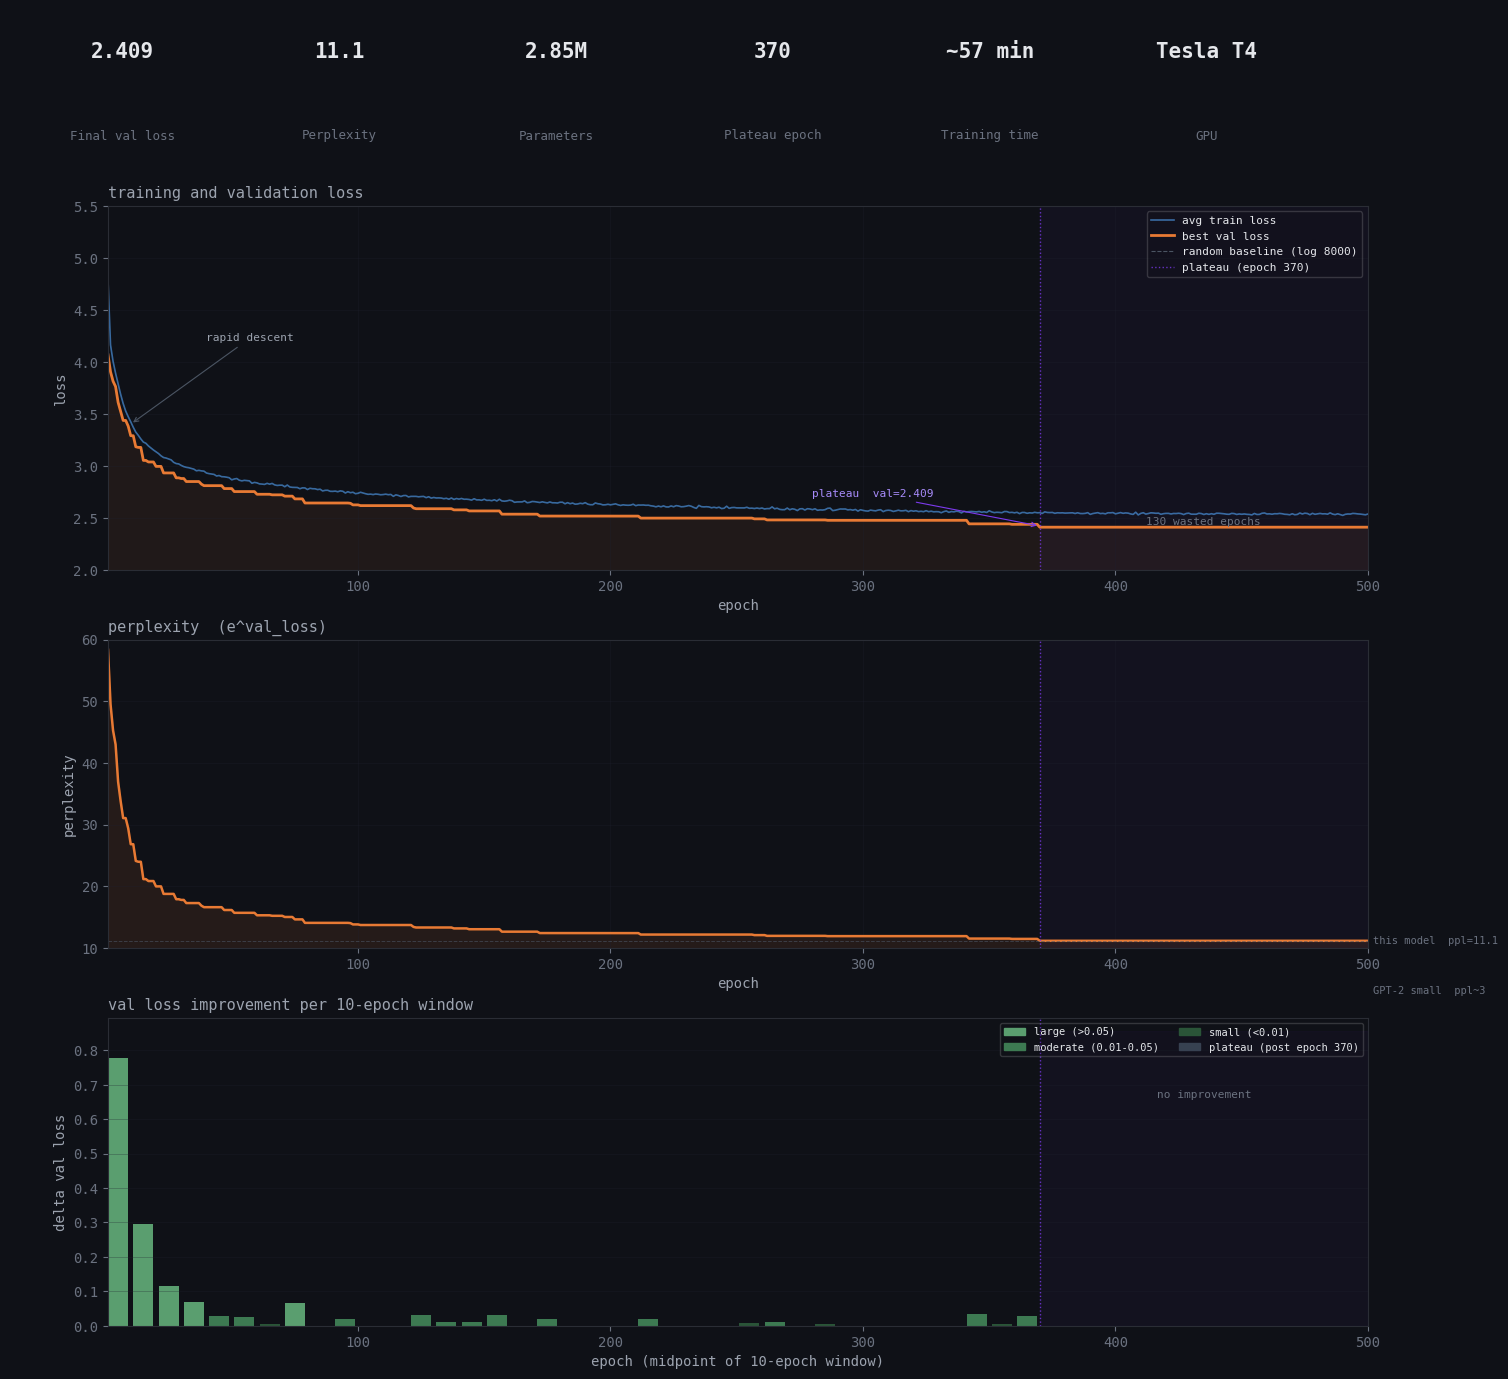

Saved: training_analysis.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

train_loss = [4.789,4.1606,4.0039,3.8897,3.7895,3.6873,3.5985,3.526,3.4721,3.4227,3.3698,3.3233,3.2921,3.2576,3.2274,3.2159,3.1904,3.1706,3.1512,3.1345,3.1171,3.095,3.0788,3.0738,3.065,3.0563,3.0325,3.0208,3.0172,3.003,2.9915,2.9847,2.9806,2.9744,2.9671,2.9515,2.9555,2.9504,2.9478,2.9298,2.924,2.9197,2.9164,2.9011,2.9058,2.8947,2.8935,2.8898,2.8845,2.8642,2.8723,2.8769,2.8606,2.8543,2.8595,2.8567,2.8544,2.8314,2.8396,2.8352,2.8252,2.8234,2.8204,2.8306,2.8228,2.8297,2.8156,2.8104,2.8128,2.813,2.7979,2.8143,2.7957,2.7921,2.7917,2.7907,2.7787,2.7871,2.7863,2.7711,2.7832,2.7787,2.7782,2.7707,2.7743,2.7575,2.7634,2.7642,2.754,2.7534,2.7559,2.7497,2.7583,2.7543,2.7377,2.7505,2.7406,2.7451,2.7309,2.7348,2.7448,2.7375,2.7308,2.7251,2.7269,2.7225,2.728,2.7253,2.7207,2.7229,2.7266,2.7213,2.7239,2.7056,2.7199,2.7138,2.7041,2.713,2.7138,2.6997,2.7052,2.7052,2.7053,2.7009,2.7036,2.7049,2.6931,2.7017,2.6886,2.6946,2.6898,2.6906,2.6892,2.6827,2.687,2.6779,2.6899,2.6758,2.6848,2.6787,2.6853,2.6775,2.6782,2.6754,2.6693,2.6825,2.6713,2.6719,2.6675,2.678,2.6667,2.6681,2.6636,2.6728,2.6611,2.6776,2.6613,2.6586,2.6618,2.6683,2.6637,2.6481,2.6518,2.6516,2.6523,2.6616,2.6443,2.6477,2.6561,2.6546,2.6501,2.6463,2.653,2.6472,2.6428,2.6514,2.6437,2.6436,2.6413,2.6489,2.6491,2.6338,2.6451,2.6347,2.6408,2.6302,2.6322,2.639,2.635,2.645,2.6307,2.6253,2.6251,2.6421,2.6346,2.6315,2.6234,2.6245,2.6293,2.6239,2.6283,2.6333,2.6241,2.6182,2.624,2.6209,2.6198,2.6215,2.6298,2.6158,2.6223,2.6215,2.6225,2.6194,2.6204,2.6147,2.6115,2.6048,2.6122,2.605,2.6137,2.6042,2.6033,2.6133,2.6053,2.6162,2.6126,2.6052,2.6067,2.6111,2.6168,2.6104,2.5988,2.5902,2.6185,2.6063,2.6041,2.6058,2.6038,2.5956,2.6005,2.5949,2.6012,2.5879,2.5912,2.6107,2.59,2.5974,2.5987,2.5946,2.5942,2.5932,2.5942,2.6006,2.5906,2.5921,2.5884,2.5932,2.5881,2.5933,2.5842,2.5878,2.5876,2.6042,2.5855,2.5916,2.5803,2.5774,2.5776,2.5929,2.5767,2.5857,2.5811,2.5689,2.5854,2.5869,2.574,2.5868,2.5841,2.5776,2.5859,2.5714,2.5752,2.5738,2.5777,2.5904,2.5924,2.5683,2.572,2.5781,2.5841,2.5834,2.5839,2.5756,2.5783,2.5725,2.5796,2.5637,2.5767,2.5704,2.5657,2.5636,2.5733,2.5689,2.5661,2.5735,2.5769,2.5587,2.5691,2.5723,2.5697,2.5603,2.5657,2.5724,2.566,2.5669,2.571,2.558,2.5685,2.5627,2.5668,2.5589,2.562,2.558,2.5677,2.5579,2.5628,2.5567,2.5584,2.5574,2.5478,2.5589,2.5651,2.5516,2.5594,2.5564,2.5629,2.5591,2.5463,2.5616,2.5556,2.5587,2.5601,2.5576,2.5558,2.5607,2.5527,2.5571,2.5506,2.5672,2.5557,2.5489,2.5524,2.551,2.5482,2.5597,2.5592,2.5497,2.5518,2.5469,2.5522,2.5389,2.5505,2.5504,2.5426,2.5473,2.5452,2.552,2.5475,2.5482,2.5412,2.5565,2.5505,2.5495,2.5507,2.5424,2.5476,2.546,2.5473,2.5444,2.5451,2.5461,2.5474,2.5408,2.5477,2.5405,2.5398,2.542,2.5488,2.5321,2.5401,2.5449,2.5487,2.5398,2.5422,2.5371,2.5476,2.5472,2.5495,2.5372,2.5432,2.5494,2.5424,2.5462,2.5442,2.5365,2.532,2.5531,2.5267,2.5416,2.548,2.535,2.5402,2.5472,2.5457,2.5426,2.5441,2.5329,2.539,2.5418,2.5418,2.536,2.5409,2.5402,2.543,2.5397,2.5303,2.5405,2.5437,2.5341,2.5341,2.5335,2.5429,2.54,2.5311,2.5386,2.5323,2.5385,2.533,2.5432,2.5429,2.5407,2.5378,2.5341,2.5329,2.5417,2.5397,2.5316,2.5363,2.5332,2.5363,2.5326,2.5314,2.5269,2.541,2.5313,2.532,2.5428,2.5457,2.5362,2.5375,2.5336,2.5387,2.5378,2.5412,2.5384,2.5332,2.532,2.5282,2.5381,2.5285,2.5316,2.5453,2.5359,2.5437,2.5406,2.5286,2.5424,2.5329,2.5368,2.5413,2.537,2.538,2.5341,2.5467,2.5346,2.5296,2.5378,2.5299,2.5225,2.5327,2.5361,2.5352,2.5416,2.5399,2.5366,2.5349,2.5318,2.5281,2.5359]
best_val   = [4.0667,3.9027,3.8127,3.7612,3.6095,3.5208,3.4354,3.4354,3.3806,3.2886,3.2886,3.1819,3.1762,3.1762,3.0511,3.0511,3.0362,3.0362,3.0362,2.9936,2.9936,2.9936,2.9306,2.9306,2.9306,2.9306,2.9306,2.8835,2.8835,2.877,2.877,2.8479,2.8479,2.8479,2.8479,2.8479,2.8479,2.8227,2.8084,2.8084,2.8084,2.8084,2.8084,2.8084,2.8084,2.8084,2.7802,2.7802,2.7802,2.7802,2.7515,2.7515,2.7515,2.7515,2.7515,2.7515,2.7515,2.7515,2.7515,2.7256,2.7256,2.7256,2.7256,2.7256,2.7256,2.7201,2.7201,2.7201,2.7201,2.7201,2.7075,2.7075,2.7075,2.7075,2.6811,2.6811,2.6811,2.6811,2.6416,2.6416,2.6416,2.6416,2.6416,2.6416,2.6416,2.6416,2.6416,2.6416,2.6416,2.6416,2.6416,2.6416,2.6416,2.6416,2.6416,2.6416,2.6388,2.6235,2.6235,2.6235,2.6165,2.6165,2.6165,2.6165,2.6165,2.6165,2.6165,2.6165,2.6165,2.6165,2.6165,2.6165,2.6165,2.6165,2.6165,2.6165,2.6165,2.6165,2.6165,2.6165,2.6165,2.5935,2.5866,2.5866,2.5866,2.5866,2.5866,2.5866,2.5866,2.5866,2.5866,2.5866,2.5866,2.5866,2.5866,2.5866,2.5866,2.5755,2.5755,2.5755,2.5755,2.5755,2.5755,2.5653,2.5653,2.5653,2.5653,2.5653,2.5653,2.5653,2.5653,2.5653,2.5653,2.5653,2.5653,2.5653,2.5342,2.5342,2.5342,2.5342,2.5342,2.5342,2.5342,2.5342,2.5342,2.5342,2.5342,2.5342,2.5342,2.5342,2.5342,2.5161,2.5161,2.5161,2.5161,2.5161,2.5161,2.5161,2.5161,2.5161,2.5161,2.5161,2.5161,2.5161,2.5161,2.5161,2.5161,2.5161,2.5161,2.5161,2.5155,2.5155,2.5155,2.5155,2.5155,2.5155,2.5155,2.5155,2.5155,2.5155,2.5155,2.5155,2.5155,2.5155,2.5155,2.5155,2.5155,2.5155,2.5155,2.5155,2.5155,2.4964,2.4964,2.4964,2.4964,2.4964,2.4964,2.4964,2.4964,2.4964,2.4964,2.4964,2.4964,2.4964,2.4964,2.4964,2.4964,2.4964,2.4964,2.4964,2.4964,2.4964,2.4964,2.4964,2.4964,2.4964,2.4964,2.4964,2.4964,2.4964,2.4964,2.4964,2.4964,2.4964,2.4964,2.4964,2.4964,2.4964,2.4964,2.4964,2.4964,2.4964,2.4964,2.4964,2.4964,2.4964,2.489,2.489,2.489,2.489,2.489,2.4787,2.4787,2.4787,2.4787,2.4787,2.4787,2.4787,2.4787,2.4787,2.4787,2.4787,2.4787,2.4787,2.4787,2.4787,2.4787,2.4787,2.4787,2.4787,2.4787,2.4787,2.4787,2.4787,2.4787,2.4751,2.4751,2.4751,2.4751,2.4751,2.4751,2.4751,2.4751,2.4751,2.4751,2.4751,2.4751,2.4751,2.4751,2.4751,2.4751,2.4751,2.4751,2.4751,2.4751,2.4751,2.4751,2.4751,2.4751,2.4751,2.4751,2.4751,2.4751,2.4751,2.4751,2.4751,2.4751,2.4751,2.4751,2.4751,2.4751,2.4751,2.4751,2.4751,2.4751,2.4751,2.4751,2.4751,2.4751,2.4751,2.4751,2.4751,2.4751,2.4751,2.4751,2.4751,2.4751,2.4751,2.4751,2.4751,2.4751,2.4411,2.4411,2.4411,2.4411,2.4411,2.4411,2.4411,2.4411,2.4411,2.4411,2.4411,2.4411,2.4411,2.4411,2.4411,2.4411,2.4411,2.4365,2.4365,2.4365,2.4365,2.4365,2.4365,2.4365,2.4365,2.4365,2.4365,2.4365,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091,2.4091]

assert len(train_loss) == 500
assert len(best_val)   == 500

epochs     = list(range(1, 501))
perplexity = [np.exp(v) for v in best_val]

improvement, improv_epochs = [], []
for i in range(0, 500, 10):
    improvement.append(round(best_val[i] - best_val[min(i + 9, 499)], 4))
    improv_epochs.append(i + 5)

plt.rcParams.update({
    'figure.facecolor': '#0f1117', 'axes.facecolor': '#0f1117',
    'axes.edgecolor': '#2a2d35',   'axes.labelcolor': '#9ca3af',
    'xtick.color': '#6b7280',      'ytick.color': '#6b7280',
    'grid.color': '#1e2130',       'grid.linewidth': 0.5,
    'text.color': '#e5e7eb',       'font.family': 'monospace', 'font.size': 10,
})

BLUE = '#4a90d9'; ORANGE = '#e87a34'; GRAY = '#4b5563'; GREEN = '#5a9e6f'; DIM = '#374151'

fig = plt.figure(figsize=(14, 14))
fig.patch.set_facecolor('#0f1117')

ax0 = fig.add_axes([0.0, 0.88, 1.0, 0.12])
ax0.set_axis_off()
for j, (label, val) in enumerate([('Final val loss','2.409'),('Perplexity','11.1'),('Parameters','2.85M'),('Plateau epoch','370'),('Training time','~57 min'),('GPU','Tesla T4')]):
    x = 0.08 + j * 0.155
    ax0.text(x, 0.75, val,   ha='center', va='center', fontsize=15, fontweight='bold', color='#e5e7eb')
    ax0.text(x, 0.25, label, ha='center', va='center', fontsize=9,  color='#6b7280')

ax1 = fig.add_axes([0.07, 0.60, 0.90, 0.26])
ax1.set_facecolor('#0f1117')
ax1.plot(epochs, train_loss, color=BLUE,   lw=1.2, alpha=0.7, label='avg train loss')
ax1.plot(epochs, best_val,   color=ORANGE, lw=2.0, label='best val loss')
ax1.axhline(9.0, color=GRAY, lw=0.8, ls='--', label='random baseline (log 8000)')
ax1.axvline(370, color='#7c3aed', lw=1.0, ls=':', alpha=0.8, label='plateau (epoch 370)')
ax1.fill_between(epochs, best_val, alpha=0.08, color=ORANGE)
ax1.fill_betweenx([2.0, 5.5], 370, 500, alpha=0.04, color='#7c3aed')
ax1.set_xlim(1, 500); ax1.set_ylim(2.0, 5.5)
ax1.set_xlabel('epoch'); ax1.set_ylabel('loss')
ax1.set_title('training and validation loss', loc='left', color='#9ca3af', fontsize=11)
ax1.grid(True, alpha=0.4)
ax1.legend(fontsize=8, framealpha=0.2, loc='upper right')
ax1.annotate('rapid descent', xy=(10, 3.4), xytext=(40, 4.2), color='#9ca3af', fontsize=8,
    arrowprops=dict(arrowstyle='->', color='#4b5563', lw=0.8))
ax1.annotate('plateau  val=2.409', xy=(370, 2.42), xytext=(280, 2.7), color='#a78bfa', fontsize=8,
    arrowprops=dict(arrowstyle='->', color='#7c3aed', lw=0.8))
ax1.text(435, 2.43, '130 wasted epochs', color='#6b7280', fontsize=8, ha='center')

ax2 = fig.add_axes([0.07, 0.33, 0.90, 0.22])
ax2.set_facecolor('#0f1117')
ax2.plot(epochs, perplexity, color=ORANGE, lw=1.8)
ax2.fill_between(epochs, perplexity, alpha=0.1, color=ORANGE)
ax2.axvline(370, color='#7c3aed', lw=1.0, ls=':', alpha=0.8)
ax2.fill_betweenx([10, 60], 370, 500, alpha=0.04, color='#7c3aed')
for ppl, lbl in [(11.1, 'this model  ppl=11.1'), (3.0, 'GPT-2 small  ppl~3')]:
    ax2.axhline(ppl, color=GRAY, lw=0.7, ls='--', alpha=0.6)
    ax2.text(502, ppl, lbl, color='#6b7280', fontsize=7.5, va='center')
ax2.set_xlim(1, 500); ax2.set_ylim(10, 60)
ax2.set_xlabel('epoch'); ax2.set_ylabel('perplexity')
ax2.set_title('perplexity  (e^val_loss)', loc='left', color='#9ca3af', fontsize=11)
ax2.grid(True, alpha=0.4)

ax3 = fig.add_axes([0.07, 0.06, 0.90, 0.22])
ax3.set_facecolor('#0f1117')
colors = [DIM if ep > 370 else (GREEN if v > 0.05 else ('#3d7a52' if v > 0.01 else '#2a5438'))
          for v, ep in zip(improvement, improv_epochs)]
ax3.bar(improv_epochs, improvement, width=8, color=colors, linewidth=0)
ax3.axvline(370, color='#7c3aed', lw=1.0, ls=':', alpha=0.8)
ax3.fill_betweenx([0, max(improvement) * 1.1], 370, 500, alpha=0.04, color='#7c3aed')
ax3.text(435, max(improvement) * 0.85, 'no improvement', color='#6b7280', fontsize=8, ha='center')
ax3.set_xlim(1, 500); ax3.set_ylim(0, max(improvement) * 1.15)
ax3.set_xlabel('epoch (midpoint of 10-epoch window)'); ax3.set_ylabel('delta val loss')
ax3.set_title('val loss improvement per 10-epoch window', loc='left', color='#9ca3af', fontsize=11)
ax3.grid(True, alpha=0.4, axis='y')
ax3.legend(handles=[
    mpatches.Patch(color=GREEN,     label='large (>0.05)'),
    mpatches.Patch(color='#3d7a52', label='moderate (0.01-0.05)'),
    mpatches.Patch(color='#2a5438', label='small (<0.01)'),
    mpatches.Patch(color=DIM,       label='plateau (post epoch 370)'),
], fontsize=7.5, framealpha=0.2, loc='upper right', ncol=2)

plt.savefig('training_analysis.png', dpi=150, bbox_inches='tight', facecolor='#0f1117', edgecolor='none')
plt.show()
print("Saved: training_analysis.png")